---
**Q5**
V plot

Total unique coordinate pairs (shift, fragment_length): 280653


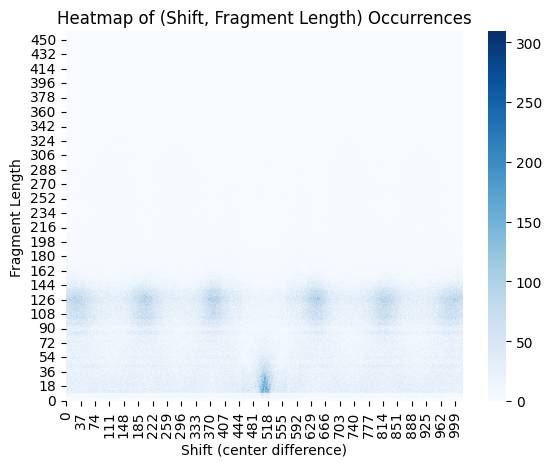

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Input file path
file_path = "mapped.bed"

# Counter to store (shift, fragment_length) frequency
coordinate_counts = Counter()

# Parse each line to extract coordinates
with open(file_path, 'r') as file:
    for line in file:
        fields = line.strip().split('\t')
        
        # Midpoints of first and second regions
        first_midpoint = (int(fields[2]) + int(fields[3])) / 2
        second_midpoint = (int(fields[8]) + int(fields[9])) / 2

        # X: center shift, Y: length of second fragment
        shift = int(second_midpoint - first_midpoint)
        fragment_length = int(fields[9]) - int(fields[8])
        
        coordinate_counts[(shift, fragment_length)] += 1

print("Total unique coordinate pairs (shift, fragment_length):", len(coordinate_counts))

# Extract sorted shift and fragment_length values
unique_shifts = sorted(set(shift for shift, length in coordinate_counts))
unique_lengths = sorted(set(length for shift, length in coordinate_counts))

# Create 2D count matrix
heatmap_matrix = np.zeros((len(unique_lengths), len(unique_shifts)))
for i, length in enumerate(unique_lengths):
    for j, shift in enumerate(unique_shifts):
        heatmap_matrix[i, j] = coordinate_counts.get((shift, length), 0)

# Draw heatmap
sns.heatmap(heatmap_matrix, cmap='Blues', annot=False, fmt='d')
plt.gca().invert_yaxis()
plt.title('Heatmap of (Shift, Fragment Length) Occurrences')
plt.xlabel('Shift (center difference)')
plt.ylabel('Fragment Length')
plt.show()
